In [5]:
using LinearAlgebra
using Plots
using Statistics
using DelimitedFiles

# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [6]:
#Função que retorna o módulo da diferença entre as normas dos nossos vetores, para conseguimos dimensionar o erro da nossa solução
get_erro(x_real, x_aprox) = abs(norm(x_real) - norm(x_aprox))

get_erro (generic function with 1 method)

In [7]:
@time get_erro([1,1,2], [1,1,1])

  0.000009 seconds (4 allocations: 160 bytes)


0.7174389352143007

### JacobiMethod(A, b, n)

Retorna uma aproximação da solução do sistema linear $Ax = b$, utilizando o método iterativo de Jacobi.

O método de Jacobi decompõe a matriz em $A = D + R$ e utiliza a iteração: $x^{(k+1)} = D^{-1}(b - Rx^{(k)})$

#### Argumentos
- `A::Matrix`: Matriz de coeficientes.
- `b::Vector`: Vetor resultante.
- `n::Int`: Número máximo de iterações.

#### Retorno
- `x::Vector`: Aproximação da solução x após as n iterações.


In [8]:
function JacobiMethod(A::Matrix , b:: Vector, ϵ:: Float64, verbose:: Bool = false, iteracoes:: Bool = false)
    m = size(A,1)
    x = ones(m) #Chute inicial

    hist_erros = Float64[]
    erro = 1
    it = 0

    while erro >= ϵ
        xᵏ = copy(x)

        for i in 1:m
            diag_inv = 1/A[i,i]
            d = diag_inv * b[i] #Cálculo do D⁻¹[i,i]*b[i]

            soma = 0
            for j in 1:m #Cálculo do D⁻¹Rx
                if j != i
                    soma = soma + diag_inv * A[i,j] * xᵏ[j] #∑D⁻¹[i,i] * A[i,j] * xᵏ[j]
                end
            end

            x[i] = d - soma # x =  D⁻¹b - D⁻¹Rx 
        end

        erro = get_erro(x, xᵏ)
        it+=1
        push!(hist_erros, erro)
    end

    if verbose
        println("Solução Aproximada Gauss Jacobi: ", x)
        println("Histórico de erros: ", hist_erros)
    end

    if iteracoes
        return x, hist_erros, it
    end
    
        
    return x, hist_erros
end

JacobiMethod (generic function with 3 methods)

In [9]:
function GaussSeidelMethod(A::Matrix , b:: Vector, ϵ:: Float64, verbose:: Bool = false, iteracoes:: Bool = false)
    m = size(A,1)
    x = ones(m) #Chute inicial

    hist_erros = Float64[]
    erro = 1
    it = 0

    while erro >= ϵ
        xᵏ = copy(x)

        for i in 1:m
            diag_inv = 1/A[i,i]
            d = diag_inv * b[i] #Cálculo do D⁻¹[i,i]*b[i]

            
            soma = 0
            for j in 1:m #Cálculo do D⁻¹Rx
                if j != i
                    soma = soma + diag_inv * A[i,j] * x[j]
                end
            end

            x[i] = d - soma
            
        end

        erro = get_erro(x, xᵏ)
        push!(hist_erros, erro)
    end

    if verbose
        println("Solução Aproximada Gauss Seidel: ", x)
        println("Histórico de erros: ", hist_erros)
    end

    if iteracoes
        return x, hist_erros, it
    end
    
    return x, hist_erros
end

GaussSeidelMethod (generic function with 3 methods)

Qual deveria ser a complexidade computacional do código que você escreveu?

Para melhor compreensão da complexidade das nossas funções, escolhi não utilizar algumas facilidades do Julia. Dessa forma, podemos perceber que em ambos possuímos 3 for's aninhados, o primeiro que vai até n e os dois últimos até m, o que configura uma complexidade $O(n*m^2)$.

## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

In [10]:
function plotar_comparativo(A, b)
    x_j, arr1 = JacobiMethod(A, b, 10^(-12))
    x_gs, arr2 = GaussSeidelMethod(A, b, 10^(-12))

    println("Solução Real :", A\b)
    println("Solução Aproximada Jacobi :", x_j)
    println("Solução Aproximada Gauss Seidel: ", x_gs)
    
    eixo_1 = 1:length(arr1)
    eixo_2 = 1:length(arr2)

    plot(eixo_1, arr1, label= "Jacobi", marker= :o, yscale= :log10)
    plot!(eixo_2, arr2, label= "Gauss-Seidel", marker= :o, yscale= :log10)

    title!("Convergência")
    xlabel!("Iterações")
    ylabel!("Erro")

end

plotar_comparativo (generic function with 1 method)

Solução Real :[0.9770114942528736, 2.1494252873563218]
Solução Aproximada Jacobi :[0.9770114942532573, 2.149425287356318]
Solução Aproximada Gauss Seidel: [0.9770114942532573, 2.149425287356212]


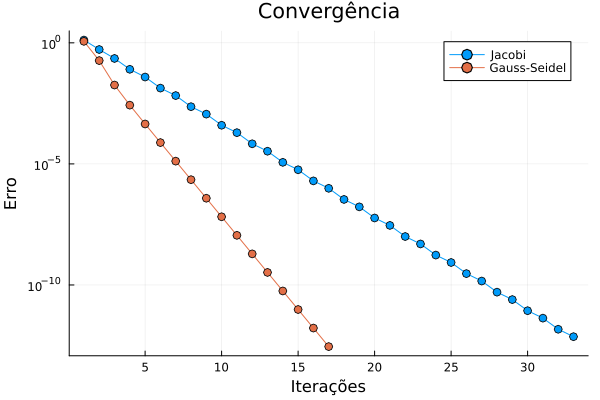

In [11]:
A = [15 9; 2 7]
b = [34, 17]

plotar_comparativo(A,b)


Solução Real :[0.3191489361702128, 0.40425531914893614]
Solução Aproximada Jacobi :[0.31914893617014073, 0.40425531914881263]
Solução Aproximada Gauss Seidel: [0.31914893617014073, 0.40425531914895774]


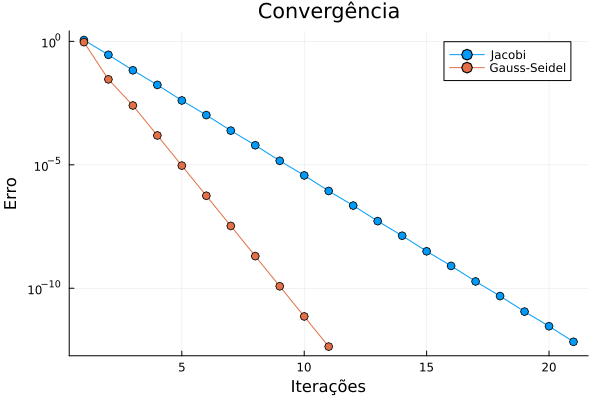

In [12]:
A = [10 2; 3 10]
b = [4, 5]

plotar_comparativo(A,b)

Solução Real :[3.7878281622911696, 1.7305489260143199, -1.2990453460620526]
Solução Aproximada Jacobi :[3.7878281622906815, 1.730548926013955, -1.2990453460624358]
Solução Aproximada Gauss Seidel: [3.787828162291648, 1.7305489260145164, -1.299045346062362]


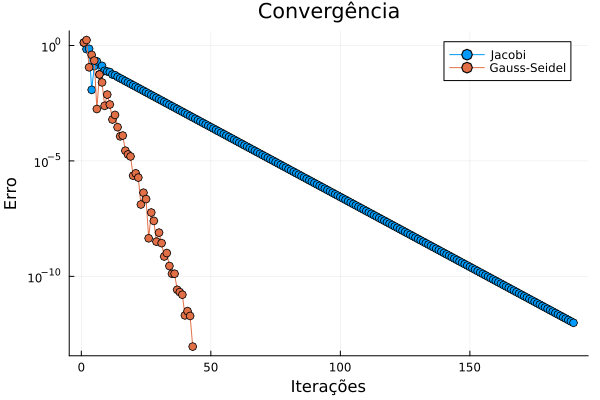

In [13]:
A = [15 9 8; 1 10 7; 21 4 35]
b = [62, 12, 41]

plotar_comparativo(A,b)


Solução Real :[2.8739649842320296, 0.19794628015721372, -0.6984511658976869]
Solução Aproximada Jacobi :[2.873964984232412, 0.19794628015744797, -0.6984511658973622]
Solução Aproximada Gauss Seidel: [2.873964984232148, 0.19794628015720284, -0.6984511658977108]


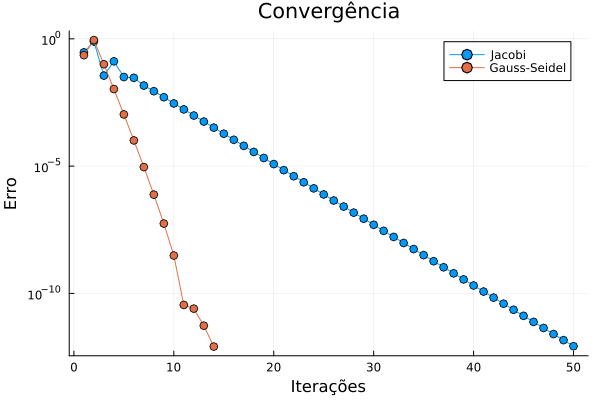

In [14]:
A = [42 16 17; 9 35 4; 13 22 54]
b = [112, 30, 4]

plotar_comparativo(A,b)

In [15]:
function plotar_comparativo_mod(A, b)
    x_j, arr1 = JacobiMethod(A, b, 10^(-12))
    x_gs, arr2 = GaussSeidelMethod(A, b, 10^(-12))

    println("Solução Real :", A\b)
    println("Solução Aproximada Jacobi :", x_j)
    println("Solução Aproximada Gauss Seidel: ", x_gs)
    
    eixo_1 = 1:length(arr1)
    eixo_2 = 1:length(arr2)

    plot(eixo_1, arr1, label= "Jacobi", marker= :o)
    plot!(eixo_2, arr2, label= "Gauss-Seidel", marker= :o)

    title!("Convergência")
    xlabel!("Iterações")
    ylabel!("Erro")

end

plotar_comparativo_mod (generic function with 1 method)

In [16]:
# Código gerando gráficos

(Comentários)

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

In [17]:
A= rand(5,5)
b= rand(5)


println("Solução Real: ", A\b)
JacobiMethod(A, b, 0.9, true) 
GaussSeidelMethod(A, b, 0.9, true)

Solução Real: [0.13714518749401566, 0.1484601724307973, -0.7612645264259513, -0.6106083948186264, 1.6941073730191358]
Solução Aproximada Gauss Jacobi: [-Inf, -Inf, -Inf, -Inf, -Inf]
Histórico de erros: [9.975183508630522, 81.98508630006302, 532.226969325727, 3644.4783505843143, 24902.64428903829, 169629.6938079991, 1.1574928348491592e6, 7.8916172327753045e6, 5.382794046177265e7, 3.6706684515239e8, 2.503439764449988e9, 1.7072665193403221e10, 1.1643391124270596e11, 7.940551102936058e11, 5.415334743624085e12, 3.693160809150239e13, 2.5186742608540075e14, 1.717692237476037e15, 1.1714369536771622e16, 7.988999209505098e16, 5.4483611897751386e17, 3.715689165101933e18, 2.5340365516279714e19, 1.728169623435767e20, 1.1785821592007404e21, 8.037728946150102e21, 5.481593814406282e22, 3.7383533232477516e23, 2.549493094403208e24, 1.7387107303181296e25, 1.1857710109988443e26, 8.086755697332259e26, 5.515029217588745e27, 3.7611556981298737e28, 2.565043924076382e29, 1.7493161305947154e30, 1.19300371274008

([-2.3168965604999717e307, Inf, -Inf, NaN, NaN], [22.02193397356233, 158.12670743952535, 1105.6962005332382, 7321.493844393442, 47090.16552442245, 297692.3145772886, 1.862313703135678e6, 1.1574702371895242e7, 7.164561601109043e7, 4.423274974534323e8  …  1.612811231079515e301, 9.911750971727842e301, 6.091401487810214e302, 3.743553706255821e303, 2.3006518909755235e304, 1.4138969382499223e305, 8.689296107047479e305, 5.340125209508327e306, 3.2818466423416747e307, NaN])

In [18]:
A= rand(30,30)
b= rand(30)


println("Solução Real: ", A\b)
JacobiMethod(A, b, 0.9, true) 
GaussSeidelMethod(A, b, 0.9, true)

Solução Real: [3.255355230432826, 0.894569199457051, -8.16316070752566, 5.304977793771789, -5.871249311319218, -5.076307907958595, -5.362056782644881, -3.4765099459099282, -4.846492318473697, -1.9980565464206115, 4.164504450026506, -3.2647159544097133, 0.3177168041406101, -8.637583899786252, 3.03682284550165, -14.48249053842157, -5.0634063598748, -4.021876715177967, 17.154147653127236, 0.20767692183902658, 0.2160092981677536, 8.05676037166709, 5.530828167964022, 12.149507514139259, 12.864569931389621, 4.308455019854603, -11.65355309282152, 5.286272049728618, 11.566983537394545, -14.265051253691292]
Solução Aproximada Gauss Jacobi: [Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf, Inf]
Histórico de erros: [254.55747776954854, 8914.026049159353, 327177.6412005462, 1.1961677577265872e7, 4.375951640813626e8, 1.6006404175755116e10, 5.85495587838976e11, 2.1416713007681945e13, 7.833971528491329e14,

([-1.5852869606358862e307, -3.536514875868642e306, 1.0770729340852652e308, -4.631136449691032e307, -1.021341642789673e308, 1.3895526197302423e307, 1.4109525937531764e308, -2.9669487103338156e307, Inf, -Inf  …  NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN], [298564.3332799778, 2.4549153158583474e9, 2.022429606606206e13, 1.6661316084566515e17, 1.3726037797995296e21, 1.1307877041379247e25, 9.315731536279548e28, 7.674548789172928e32, 6.322498548612994e36, 5.208643399805825e40  …  4.643846358627824e275, 3.825724830080892e279, 3.1517344341732744e283, 2.596483120126417e287, 2.1390522373975998e291, 1.7622084421996587e295, 1.4517544450142977e299, 1.195994139029315e303, 9.852919586400064e306, NaN])

In [19]:
A= rand(50, 50)
b= rand(50)


println("Solução Real: ", A\b)
JacobiMethod(A, b, 0.9, true) 
GaussSeidelMethod(A, b, 0.9, true)

Solução Real: [0.05550339026807334, 0.6430889841060001, 0.6356605731157018, 1.7559784655489274, -0.3498620906011676, 0.2585032849043122, -0.28918718951464945, -1.6620652983815123, 0.9520957658724061, 0.29258028034334066, 0.3142911724837901, -0.5878809455691675, -1.7738809652676266, 0.637798102879963, 1.7440711789572068, -0.18857202083551958, -0.5195570795195171, 0.018579803655150873, -1.8134084893063946, 1.0311122055790292, -1.1620592914915762, 0.38002161746341057, 0.10337426225368423, 0.10393482457264659, 0.009233821305743382, 0.030357285898801326, 2.1745006721484184, -0.9115764825746377, -0.6696669733236937, -0.011169264154608144, 0.596040095556334, 0.7765751685801348, 0.14511090722049402, 0.44014415891890435, 1.0673246551869053, 0.07483410071621423, -0.9501206800929443, 1.9713351926483793, -1.3082664104308483, 0.14984433501315175, 1.2729559328958908, -1.3942551381729593, 0.47377496809364633, -0.8360434345803992, -0.9052547388317921, -1.1584906894777596, -0.16326236411669093, 0.19939

([-2.6806729786741332e302, 5.214040684616935e302, -5.196056270748178e302, -3.0015123783407735e303, 5.3882233033603515e303, -3.0786656872819507e303, 3.2114035617168684e303, -1.9708081269379657e304, -3.5746670885346904e303, 1.1249893386012671e305  …  NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN], [1.3256050672224697e12, 7.501394770692631e22, 4.2449235921746534e33, 2.4021367831221483e44, 1.3593321527543412e55, 7.692250976275022e65, 4.3529261749683135e76, 2.4632537787917724e87, 1.3939173178778077e98, 7.887963090967878e108  …  2.6560939361065588e216, 1.5030425883545028e227, 8.505486164088612e237, 4.813123423648465e248, 2.723672303305154e259, 1.5412841439599565e270, 8.721889228523044e280, 4.9355825798077275e291, 2.7929700508506174e302, NaN])

Em geral, os métodos não funcionam para matrizes `rand(m,m)`.

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?

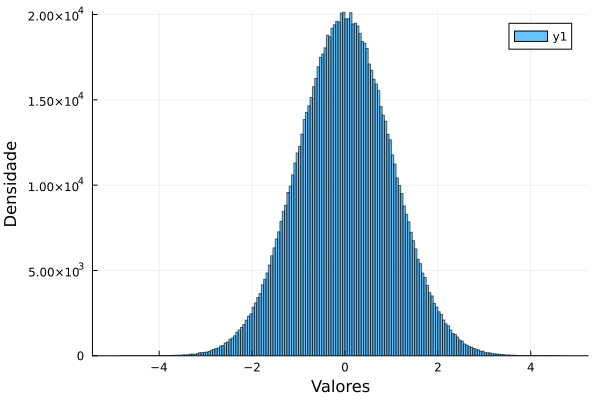

In [185]:
dist = randn(1000000)

histogram(dist, bins= :auto, xlabel= "Valores", ylabel= "Densidade", alpha= 0.6)

In [332]:
data_k_max = Float64[]

for dim in 2:10
    data = Float64[]
    println(dim)
    for i in 1:100000
        A = randn(dim,dim)
        diagonal = diag(A)
        A[diagind(A)] .= 0
        T_J = Diagonal(diagonal)\A

        r_J = maximum(abs, eigvals(Matrix(T_J)))
        k_max = r_J - 1
        push!(data, k_max)
    end
    k95 = quantile(data, 0.95)
    push!(data_k_max, k95)
end

2
3
4
5
6
7
8
9
10


In [333]:
data_k_max

9-element Vector{Float64}:
  5.143469435838197
 10.243120198729413
 15.084603296456025
 20.147414541589107
 25.10683383584499
 29.838656861748728
 34.3025504712563
 39.33830725267332
 43.607715605333205

In [ ]:
data_k_min = Float64[]

for dim in 2:50
    data = Float64[]
    println(dim)
    for i in 1:100000
    A = randn(dim,dim)
    diagonal = diag(A)
    A[diagind(A)] .= 0

    row_sums = sum(abs.(A), dims= 2)
    max_norm, row_idx = findmax(row_sums)
    k_min = max_norm - diagonal[row_idx[1]]
    push!(data, k_min)
    end
    k95 = quantile(data, 0.95)
    push!(data_k_min, k95)
end

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [27]:
data_k_min

49-element Vector{Float64}:
  3.0812372783574564
  4.454530890015937
  5.7607507304930925
  7.015811251899887
  8.230792945748036
  9.415077383357652
 10.562557482601044
 11.717502713809232
 12.838507709658655
 13.964033557567097
  ⋮
 45.50898638120654
 46.44500136061026
 47.45165825553313
 48.40087723984921
 49.38551962626112
 50.35281575410611
 51.29469846688969
 52.26442331664855
 53.22196854677488

In [28]:
eixo_x = 2:50

2:50

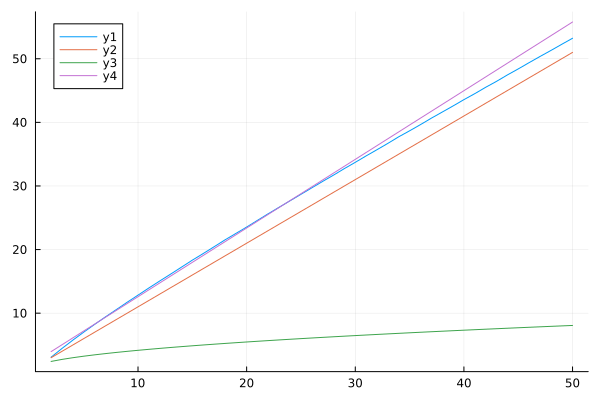

In [29]:
plot(2:50, data_k_min)
plot!(eixo_x, eixo_x .+ 1)
plot!(eixo_x, sqrt.(eixo_x) .+ 1)
plot!(eixo_x, 1.7992749418770098 .+ 1.0795403015420795.*eixo_x)

In [30]:
function createPhi(vetor, n)
    Phi = zeros(size(vetor, 1), n+1)
    for i in 1:n+1
        Phi[:,i] .+= vetor.^(i-1)
    end 
    return Phi

end

createPhi (generic function with 1 method)

In [31]:
Phi1 = createPhi([2:30;], 1)

29×2 Matrix{Float64}:
 1.0   2.0
 1.0   3.0
 1.0   4.0
 1.0   5.0
 1.0   6.0
 1.0   7.0
 1.0   8.0
 1.0   9.0
 1.0  10.0
 1.0  11.0
 ⋮    
 1.0  22.0
 1.0  23.0
 1.0  24.0
 1.0  25.0
 1.0  26.0
 1.0  27.0
 1.0  28.0
 1.0  29.0
 1.0  30.0

In [32]:
function linear_regression_PI(Phi, target)
    PhiTPhi = transpose(Phi)*Phi
    pinv = inv(PhiTPhi)*transpose(Phi)
    w_learned = pinv*target
    return w_learned


end

linear_regression_PI (generic function with 1 method)

In [33]:
w_learned = linear_regression_PI(Phi1, data_k_min[1:29])

2-element Vector{Float64}:
 1.7937429621445085
 1.0798894110323392

In [34]:
f(m) =   1.7992749418770098 + m * 1.0795403015420795 

function test(dim)
data = Float64[]

for i in 1:100
    A = randn(dim,dim) + f(dim)*Matrix(I,dim, dim)
    D = Diagonal(1 ./ diag(A))
    A[diagind(A)] .= 0
    M = D*A

    row_sums = sum(abs.(M), dims= 2)
    max_norm, row_idx = findmax(row_sums)
    k = max_norm
    push!(data, k)
end
    resultado = count(x -> x < 1, data)
    # resultado/length(data)
    println(resultado/length(data))

end

test (generic function with 1 method)

Solução Real :[5.991314675263159e-6, 0.0003540196650495928, 0.00014467661146933523, 0.00015843795068249213, 0.00021102374511212715, 0.00014358292944204872, 0.00027769755743562997, 3.5336567567529435e-5, 0.00027758956796260177, 0.0003691364018919027, 0.00027052447184087514, 0.00015756248070710702, 0.00019724783379307474, 0.00010545821529656075, 0.0002379122876962016, 0.00022840664159270657, 0.00030844403443213016, 0.00016834357288490997, 0.00036664448963378914, 0.0004183466513671473, 8.949194204024762e-5, 0.00014842171964933219, 0.000247920688611343, 0.00044855193794833445, 6.934491456963956e-5, 8.804753994943317e-6, 4.2276506128860366e-5, 0.00010688444496989828, 0.00024706504793921394, 0.0002634467212718035, 0.00042835599692896386, 4.522662847099848e-5, 1.5314605936911526e-5, 0.00014659684535173892, 0.0001634033251992608, 0.00032318068099614864, 0.00022534292068845704, 0.0003720639238785087, 0.0004072111362735256, 0.00041945975815745675, 0.0002584385162995976, 0.00015160784534100352, 0

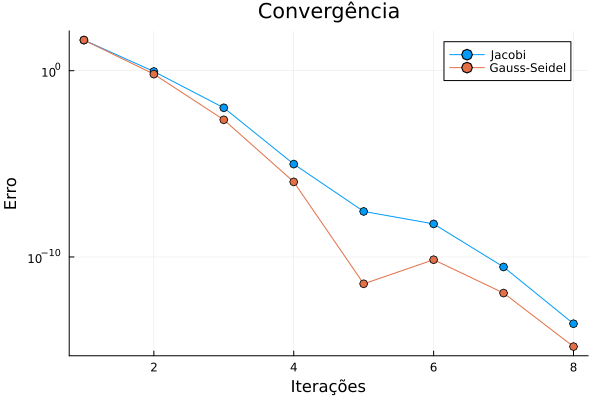

In [35]:
dim =2000

A = randn(dim,dim) + f(dim)*Matrix(I,dim, dim) 
b = rand(dim)

plotar_comparativo(A,b)

In [36]:
test(1000)

1.0


Solução Real :[-0.08780041606676628, -0.09437994094548095, -0.2900346881121415, 0.21004343109466267]
Solução Aproximada Jacobi :[-0.08780041606677297, -0.09437994094538796, -0.29003468811208233, 0.21004343109462895]
Solução Aproximada Gauss Seidel: [-0.0878004160667751, -0.0943799409454892, -0.2900346881121437, 0.210043431094666]


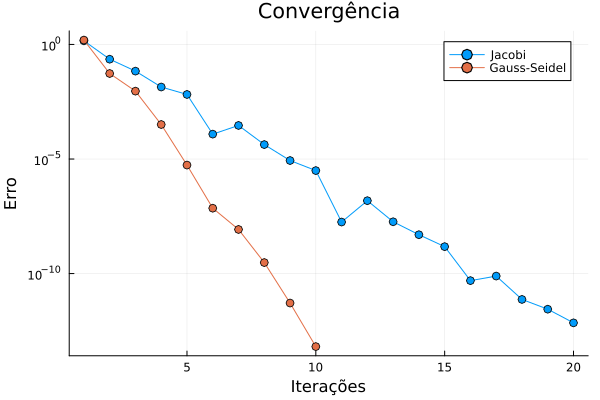

In [184]:
dim = 4
A = randn(dim,dim) + f(dim)*Matrix(I,dim, dim)
b = randn(dim)

plotar_comparativo(A,b)

Solução Real :[0.11677951397393684, -0.013258131811547988, 0.150189215739491, 0.16059883223453375]
Solução Aproximada Jacobi :[0.116779513973975, -0.013258131811545715, 0.15018921573951913, 0.16059883223460047]
Solução Aproximada Gauss Seidel: [0.11677951397399097, -0.013258131811605237, 0.15018921573948704, 0.1605988322345401]


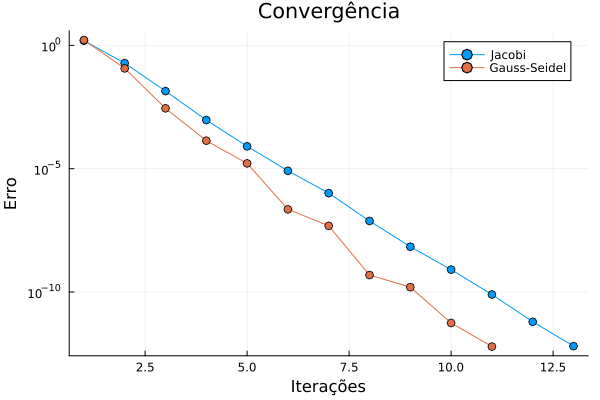

In [117]:
A = [6.257870587643096 -0.6715755198321264 0.7494903406916972 -0.9266840508086808; 1.5036119904474987 5.629539445470001 1.4401914651661705 -1.2489655911325206; 0.4792422124752973 0.4932666088088095 6.516543239783918 -0.273027790121444; -0.32527102538733504 0.35896411342631523 -0.698790388936211 5.574212197827438]
b = rand(4)

plotar_comparativo(A,b)

Solução Real :[-0.018331617297912498, 0.16490280335469729, 0.03101411603785629, 0.02233138166134247]
Solução Aproximada Jacobi :[-0.018331617298145524, 0.16490280335505572, 0.03101411603780599, 0.022331381661281416]
Solução Aproximada Gauss Seidel: [-0.018331617297823975, 0.16490280335497376, 0.031014116037744205, 0.0223313816612598]


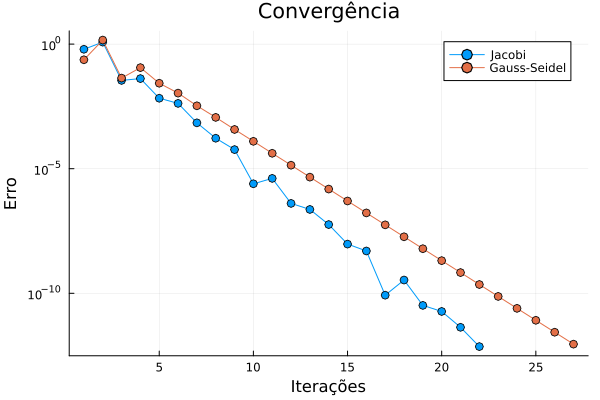

In [108]:
A = [4.571493543551633 1.2936884214383129 0.5079548920865203 2.012431363288344; 
    1.1047725846900291 4.296368358413952 -0.410875767911238 -4.607158153656866; 
    0.08311985322957496 1.0469403584540433 5.0183555008347716 1.0669037631203093; 
    1.336639769865952 1.4146785630011784 -0.8458322601947313 7.308874646781852]

b = rand(4)

plotar_comparativo(A,b)

Solução Real :[0.12740593388738924, 0.0914248155297174, 0.03709224064004964, 0.11006199515304146]
Solução Aproximada Jacobi :[0.1274059338881664, 0.09142481553094725, 0.03709224063719947, 0.11006199514887804]
Solução Aproximada Gauss Seidel: [0.12740593388737914, 0.09142481552968934, 0.03709224064004356, 0.11006199515303744]


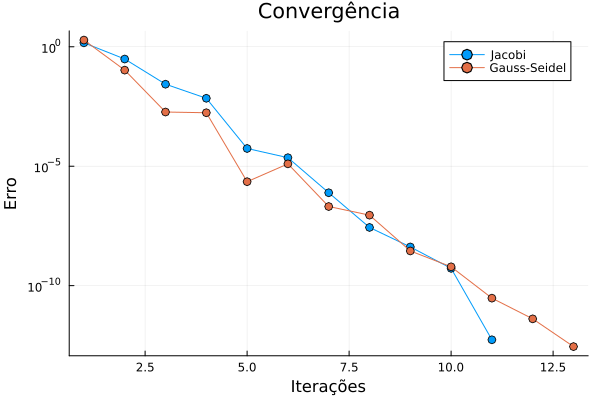

In [70]:
A = [5.879740573825972 0.47354030276834536 0.8701610671258377 -0.4425635920202793; 1.5317977459642078 6.08431911648492 2.121375514205296 -1.131224666113874; 0.447137040012305 -1.0755135088786671 5.945644358500802 -0.10563860059446259; -1.8618367541722909 -0.263916937448599 -0.28485901453121076 6.938636027635292]
b = rand(4)
plotar_comparativo(A,b)

Solução Real :[0.14587610282627755, 0.18369088749786008, 0.04868148221502789, 0.0946991543978824]
Solução Aproximada Jacobi :[0.14587610282636632, 0.18369088749827447, 0.04868148221494391, 0.09469915439787145]
Solução Aproximada Gauss Seidel: [0.14587610282778882, 0.18369088749740864, 0.048681482215005095, 0.09469915439812174]


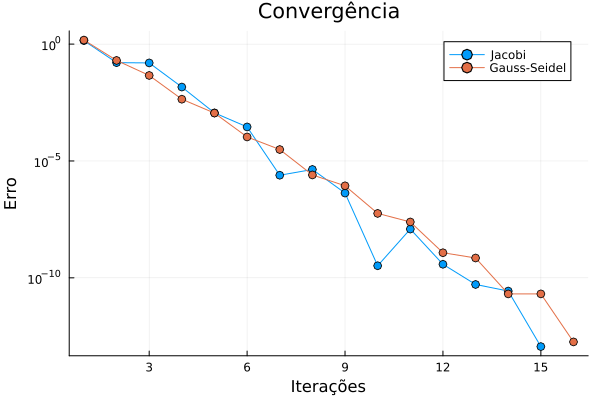

In [41]:
A = [5.158922017390697 -1.671603972262563 0.7614681094500879 -0.3505385538844801; 0.2642035053730479 6.131209610230878 1.888469340710851 -3.3599435813060095; 0.5538856264048961 1.5901424376537596 5.999509727705832 -0.01467126938138116; -0.7311045874188881 0.9355762831430736 -1.107741865970649 6.275688489741414]
b = rand(4)
plotar_comparativo(A,b)

In [42]:
# Código (gerando possivelmente gráficos ou tabelas)

(Comentários)

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

(Explique suas ideias, verifique abaixo)

In [43]:
# Código
it_j = 1
it_gs = 0

for it_j > it_gs
    A = randn(4,4) + f(4)*Matrix(I,4, 4)
    b = rand(4)

    x_j, hist_j, it_j = JacobiMethod(A,b,10^(-12),false,true)
    x_gs, hist_gs, it_gs =GaussSeidelMethod(A,b,10^(-12),false,true)

    if it_j < it_gs
        println(A)
    end
end

Base.Meta.ParseError: ParseError:
# Error @ c:\Users\sodre\github_repos\fgv_aln\Trab_2\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X63sZmlsZQ==.jl:5:9

for it_j > it_gs
#       └──────┘ ── invalid iteration spec: expected one of `=` `in` or `∈`

In [44]:
dim = 4
found = false

for i in 1:10000 
    A = randn(dim, dim) + 5.78 * I 
    
    D = Diagonal(diag(A))
    L = tril(A, -1)
    U = triu(A, 1)

    T_J = D \ (L + U)
    T_GS = (D + L) \ U

    r_J = maximum(abs, eigvals(Matrix(T_J)))
    r_GS = maximum(abs, eigvals(Matrix(T_GS)))

    if r_J < r_GS 
        println("Matriz encontrada na iteração")
        println("A = ", A)
        println("ρ(Jacobi) = $r_J")
        println("ρ(Gauss-Seidel) = $r_GS")
        global found = true
        break
    end
end


Matriz encontrada na iteração
A = [5.421529909606745 -0.9808451170924303 0.952590548411066 -0.8024792921332992; 1.0745834785416546 4.9715146818191425 0.6666174468339862 -0.10046498414981352; 0.37813927564793515 0.1811525319864138 7.103964084742568 0.5734188673494256; -1.3253646302048316 -1.496139260568807 0.3952645104193068 7.583241027607331]
ρ(Jacobi) = 0.08263838394511938
ρ(Gauss-Seidel) = 0.09879454649328138


Solução Real :[0.237429065523407, -0.33987992797635613, -0.004053885936465633, -0.12326966826362296]
Solução Aproximada Jacobi :[0.23742906552332066, -0.339879927976359, -0.004053885936534371, -0.12326966826366245]
Solução Aproximada Gauss Seidel: [0.237429065523505, -0.33987992797604993, -0.004053885936589743, -0.12326966826371451]


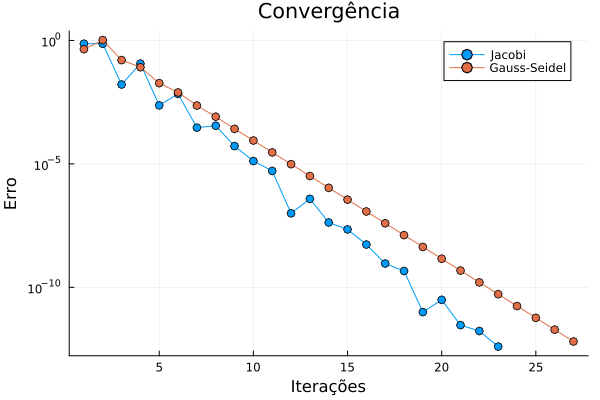

In [189]:
A = [4.571493543551633 1.2936884214383129 0.5079548920865203 2.012431363288344; 
    1.1047725846900291 4.296368358413952 -0.410875767911238 -4.607158153656866; 
    0.08311985322957496 1.0469403584540433 5.0183555008347716 1.0669037631203093; 
    1.336639769865952 1.4146785630011784 -0.8458322601947313 7.308874646781852]

b = randn(4)

plotar_comparativo(A,b)

## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à matriz $A$ acima?  O que acontece se esta perturbação acontecer apenas fora da diagonal?

Solução Real :[-0.09439877641935576, 0.26452912401330714, -0.06160662922877281, 0.05601593589228186]
Solução Aproximada Jacobi :[-0.09439877641975872, 0.2645291240134321, -0.061606629229029104, 0.0560159358921066]
Solução Aproximada Gauss Seidel: [-0.0943987764193204, 0.264529124013422, -0.06160662922882499, 0.05601593589224627]


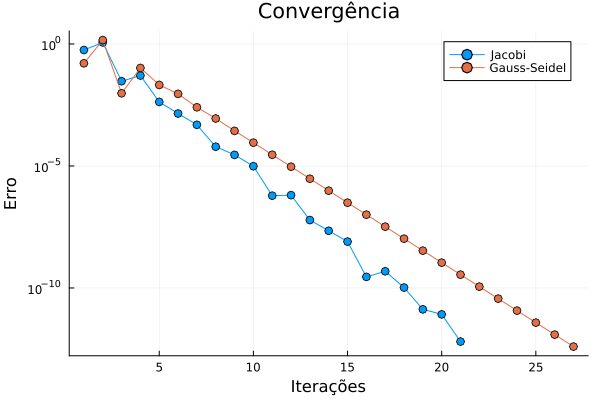

In [287]:
A = [4.571493543551633 1.2936884214383129 0.5079548920865203 2.012431363288344; 
    1.1047725846900291 4.296368358413952 -0.410875767911238 -4.607158153656866; 
    0.08311985322957496 1.0469403584540433 5.0183555008347716 1.0669037631203093; 
    1.336639769865952 1.4146785630011784 -0.8458322601947313 7.308874646781852]

ruido = ones(4,4) ./ 10

b = rand(4)

plotar_comparativo(A + ruido,b)

Solução Real :[0.03780013378341471, -0.0008825627006792631, 0.11161951979116777, 0.009256763994223104]
Solução Aproximada Jacobi :[0.037800133782654795, -0.0008825626998728488, 0.11161951979074304, 0.009256763994250584]
Solução Aproximada Gauss Seidel: [0.037800133782819836, -0.0008825627002529389, 0.11161951979103792, 0.009256763994294285]


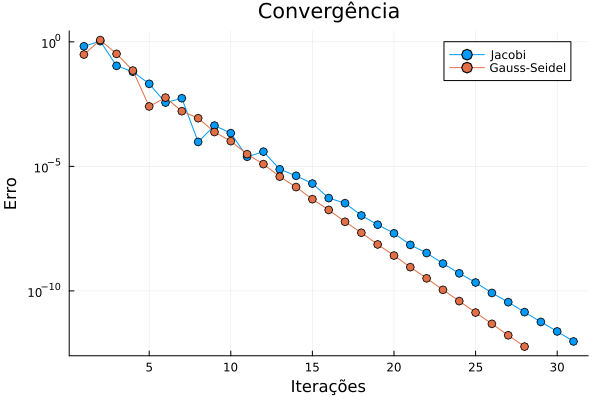

In [298]:
A = [4.571493543551633 1.2936884214383129 0.5079548920865203 2.012431363288344; 
    1.1047725846900291 4.296368358413952 -0.410875767911238 -4.607158153656866; 
    0.08311985322957496 1.0469403584540433 5.0183555008347716 1.0669037631203093; 
    1.336639769865952 1.4146785630011784 -0.8458322601947313 7.308874646781852]

ruido = rand(4,4)

b = rand(4)

plotar_comparativo(A + ruido,b)

[0.0 0.1 0.1 0.1; 0.1 0.0 0.1 0.1; 0.1 0.1 0.0 0.1; 0.1 0.1 0.1 0.0]Solução Real :[-0.0024567688734486925, 0.24189173365870875, 0.04433410385504779, 0.045413678846129395]
Solução Aproximada Jacobi :[-0.002456768873333681, 0.2418917336585747, 0.04433410385508771, 0.04541367884617049]
Solução Aproximada Gauss Seidel: [-0.002456768873365739, 0.24189173365898636, 0.04433410385492072, 0.04541367884604258]


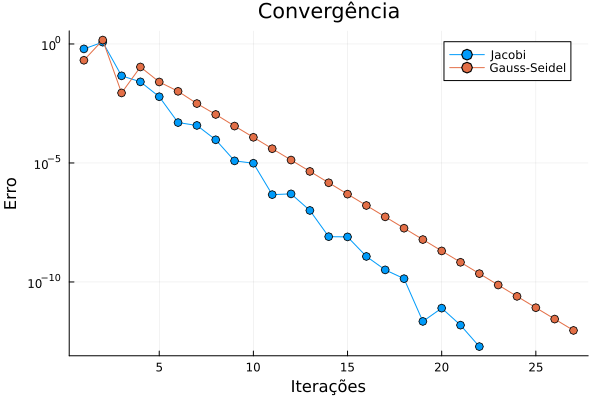

In [ ]:
A = [4.571493543551633 1.2936884214383129 0.5079548920865203 2.012431363288344; 
    1.1047725846900291 4.296368358413952 -0.410875767911238 -4.607158153656866; 
    0.08311985322957496 1.0469403584540433 5.0183555008347716 1.0669037631203093; 
    1.336639769865952 1.4146785630011784 -0.8458322601947313 7.308874646781852]

ruido = ones(4,4) ./ 10
ruido[diagind(ruido)] .= 0
b = rand(4)

plotar_comparativo(A + ruido,b)

Solução Real :[0.00598298756443003, 0.1672169220197474, 0.024554945653484032, 0.05481097692851972]
Solução Aproximada Jacobi :[0.005982987565477119, 0.16721692201963698, 0.024554945654129273, 0.0548109769289585]
Solução Aproximada Gauss Seidel: [0.005982987564112627, 0.1672169220199324, 0.024554945653455104, 0.054810976928532436]


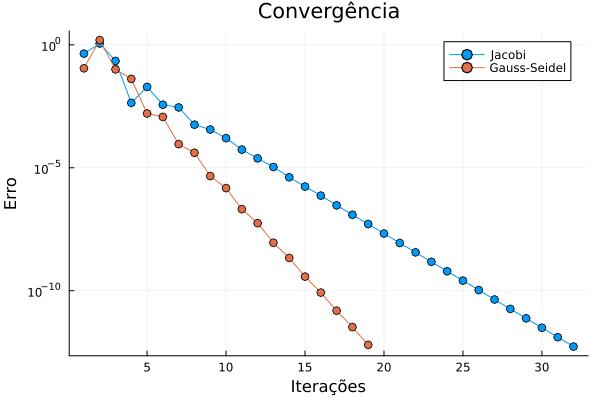

In [326]:
A = [4.571493543551633 1.2936884214383129 0.5079548920865203 2.012431363288344; 
    1.1047725846900291 4.296368358413952 -0.410875767911238 -4.607158153656866; 
    0.08311985322957496 1.0469403584540433 5.0183555008347716 1.0669037631203093; 
    1.336639769865952 1.4146785630011784 -0.8458322601947313 7.308874646781852]

ruido = rand(4,4) 
ruido[diagind(ruido)] .= 0
b = rand(4)

plotar_comparativo(A + ruido,b)

(Comentários)